# Algoritmo de Grover — base experimental para comparación clásico vs cuántico

**TFG — Comparación del algoritmo de búsqueda de Grover en entornos clásicos vs cuánticos**

Este notebook construye el **primer pilar** del trabajo experimental: el algoritmo de Grover
para un problema de búsqueda **no estructurada** de tamaño fijo `n = 3` (espacio de `N = 2³ = 8`
elementos), verificado en **simulador ideal** y dejado **listo para reutilizarse sin reescribir nada**
en los otros tres entornos:

| Entorno | Qué mide                       | Estado en este notebook     |
|---|--------------------------------|-----------------------------|
| 1. Clásico (búsqueda lineal) | nº de consultas de media       | ✔ implementado              |
| 2. Simulador ideal (sin ruido) | probabilidad de éxito teórica  | ✔ implementado |
| 3. Simulador con ruido | degradación por ruido modelado | ✔ implementado              |
| 4. Hardware cuántico real | degradación física real        | ✔ implementado              |

> **Principio rector — *fuente única de verdad*.** El problema de búsqueda se define **una sola vez**.
> Tanto el comprobador clásico como el oráculo cuántico se **derivan** de esa única definición. Así, por
> construcción, los cuatro entornos atacan **literalmente la misma instancia** del problema. Es la condición
> imprescindible para que la comparación sea honesta.


## 1. Imports y versiones

Fijamos e imprimimos las versiones para que el experimento sea **reproducible** (un tribunal valorará que
cualquiera pueda repetir tus resultados con el mismo entorno).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

import qiskit_aer

print("Qiskit     :", qiskit.__version__)
print("Qiskit Aer :", qiskit_aer.__version__)

# Semilla global para reproducibilidad de las partes aleatorias (elección de w, etc.)
SEED = 42

Qiskit     : 2.4.2
Qiskit Aer : 0.17.2


## 2. Definición del problema — *la fuente única de verdad*

### 2.1 El problema de búsqueda no estructurada

El espacio de búsqueda son **todas las cadenas de `n` bits**, es decir los enteros `0, 1, ..., N-1`
con `N = 2ⁿ`. No hay orden ni estructura explotable: es el escenario donde la ventaja cuadrática de
Grover es legítima (si hubiera estructura, un algoritmo clásico la aprovecharía y la comparación dejaría
de ser justa).

Marcamos **un** elemento objetivo `w` (caso canónico de una sola solución, `M = 1`). La función de
búsqueda —el "oráculo lógico"— es:

$$ f(x) = \begin{cases} 1 & \text{si } x = w \\ 0 & \text{en caso contrario} \end{cases} $$

Esta función `f` es **la misma** en los dos mundos:
- en el **clásico**, "buscar" es ir evaluando `f(x)` hasta que dé 1;
- en el **cuántico**, `f` define el oráculo de fase que invierte el signo de la amplitud de `|w⟩`.

Por eso "una consulta" significa exactamente lo mismo en ambos lados, y comparar `√N` vs `N` consultas
es legítimo.


In [3]:
def marked_element(n, seed=SEED):
    '''FUENTE ÚNICA DE VERDAD del problema de búsqueda.

    Dado el número de qubits n, devuelve el elemento marcado w (un entero en [0, 2^n)).
    TODO lo demás (comprobador clásico y oráculo cuántico) se deriva de este w,
    de modo que los cuatro entornos atacan exactamente la misma instancia.

    La elección es aleatoria pero reproducible (depende de la semilla). Aleatorizar
    la posición de w es importante: si lo fijáramos en un valor "cómodo", el caso
    medio clásico (N/2) quedaría sesgado.
    '''
    rng = np.random.default_rng(seed)
    return int(rng.integers(0, 2**n))


def make_checker(w):
    '''Deriva el comprobador clásico a partir del MISMO w.

    Devuelve la función f(x) = (x == w). Es la versión clásica del oráculo.
    '''
    return lambda x: x == w


# --- Parámetros fijos del experimento -------------------------------------
n = 3                      # nº de qubits  ->  N = 8 elementos
N = 2**n
w = marked_element(n)      # elemento marcado (mismo para los 4 entornos)
checker = make_checker(w)  # comprobador clásico derivado del mismo w

# Convención de cadena de bits:
#   format(w, '0{n}b') produce la cadena con el bit MÁS significativo a la izquierda,
#   que es EXACTAMENTE el orden en que Qiskit devuelve las claves de 'counts'
#   (q_{n-1} ... q_1 q_0). Mantener esta convención evita el error de comparar el
#   resultado medido con w.
w_str = format(w, f"0{n}b")

print(f"n = {n}  ->  N = {N} elementos")
print(f"Elemento marcado w = {w}  (cadena de bits: '{w_str}')")

n = 3  ->  N = 8 elementos
Elemento marcado w = 0  (cadena de bits: '000')


## 3. Entorno 1 — Búsqueda clásica (referencia O(N))

La búsqueda lineal recorre los elementos preguntando `f(x)` hasta encontrar `w`. Contamos el número de
**consultas** (cada evaluación de `f` es una consulta), que es la métrica comparable con el lado cuántico.

- Mejor caso: 1 consulta (w está el primero).
- Peor caso: N consultas (w está el último).
- **Caso medio: N/2**, pero esto **solo emerge si promediamos sobre la posición de `w`**. Por eso, además
  de buscar en orden natural, promediamos sobre todas las posiciones posibles barajando el orden de recorrido.


In [4]:
def classical_search(n, checker, order=None):
    '''Búsqueda lineal. Devuelve (elemento_encontrado, nº_de_consultas).

    'order' permite fijar el orden de recorrido; si es None se usa el orden natural 0..N-1.
    Cada iteración del bucle = 1 consulta al oráculo clásico.
    '''
    if order is None:
        order = range(2**n)
    queries = 0
    for x in order:
        queries += 1
        if checker(x):           # <- una consulta al oráculo clásico f(x)
            return x, queries
    return None, queries


# Búsqueda en orden natural
found, q_natural = classical_search(n, checker)
print(f"Orden natural : encontrado {found} en {q_natural} consultas")

# Caso medio empírico: promediamos sobre muchos órdenes aleatorios
rng = np.random.default_rng(SEED)
trials = 2000
total = 0
for _ in range(trials):
    order = rng.permutation(N)
    _, q = classical_search(n, checker, order=order)
    total += q
mean_classical = total / trials
print(f"Caso medio empírico (sobre {trials} órdenes aleatorios): {mean_classical:.3f} consultas")
print(f"Predicción teórica del caso medio (N+1)/2 = {(N+1)/2:.3f}")

Orden natural : encontrado 0 en 1 consultas
Caso medio empírico (sobre 2000 órdenes aleatorios): 4.535 consultas
Predicción teórica del caso medio (N+1)/2 = 4.500


## 4. Bloques cuánticos

Construimos Grover como **piezas independientes y reutilizables**: oráculo, difusor, cálculo del número
óptimo de iteraciones y ensamblaje del circuito completo. Esta separación es la que nos permitirá no
reescribir nada al cambiar de entorno.

### 4.1 El oráculo de fase

El oráculo cuántico debe **marcar** el estado `|w⟩` invirtiendo el signo de su amplitud, y dejar intactos
los demás:

$$ U_w\,|x\rangle = (-1)^{f(x)}\,|x\rangle \quad\Rightarrow\quad U_w\,|w\rangle = -|w\rangle,\quad U_w\,|x\rangle = |x\rangle \ (x\neq w) $$

**Cómo se construye** (técnica estándar de "abrir y cerrar con X"):
1. Aplicamos `X` a cada qubit cuyo bit en `w` valga 0. Tras esto, el estado objetivo `|w⟩` se ha
   transformado en `|11...1⟩`.
2. Aplicamos una **Z multicontrolada** (MCZ): pone un signo `-1` solo cuando todos los qubits valen 1,
   es decir, solo sobre el estado que ahora representa a `|w⟩`. Como Qiskit no tiene MCZ directa, la
   fabricamos con la identidad `MCZ = H · MCX · H` sobre el qubit objetivo (H convierte la X controlada
   en una Z controlada).
3. **Deshacemos** las `X` del paso 1 para devolver el resto del espacio a su estado original.

El resultado neto: solo `|w⟩` cambia de signo. Nada más.


In [5]:
def build_oracle(n, w):
    '''Oráculo de fase que marca |w> con un signo negativo.

    Deriva su comportamiento del MISMO w que usa el lado clásico.
    '''
    qc = QuantumCircuit(n, name="Oraculo")

    # (1) Llevar |w> a |11...1>: X en los qubits cuyo bit de w es 0.
    for i in range(n):
        if not ((w >> i) & 1):
            qc.x(i)

    # (2) Z multicontrolada sobre |11...1> mediante  MCZ = H · MCX · H.
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)   # X controlada por los n-1 primeros qubits
    qc.h(n - 1)

    # (3) Deshacer las X para no alterar el resto del espacio.
    for i in range(n):
        if not ((w >> i) & 1):
            qc.x(i)

    return qc


oracle = build_oracle(n, w)
print("Oráculo para w =", w_str)
print(oracle.draw(output="text"))

Oráculo para w = 000
     ┌───┐          ┌───┐     
q_0: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_1: ┤ X ├───────■──┤ X ├─────
     ├───┤┌───┐┌─┴─┐├───┤┌───┐
q_2: ┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘


### 4.2 El difusor (inversión sobre la media)

Tras el oráculo, la amplitud de `|w⟩` es negativa pero su **magnitud** apenas ha cambiado: medir aquí no
ayudaría. El **difusor** (operador de difusión de Grover) realiza una *inversión sobre la media*: refleja
todas las amplitudes respecto a su valor promedio, amplificando la del estado marcado (que está por debajo
de la media tras el oráculo) y reduciendo las demás.

Algebraicamente es la reflexión $D = 2|s\rangle\langle s| - I$ respecto al estado de superposición uniforme
$|s\rangle$. Se implementa con el patrón estándar:

$$ D = H^{\otimes n}\,\big(2|0\rangle\langle 0| - I\big)\,H^{\otimes n} $$

donde el bloque central ($2|0\rangle\langle0|-I$) es, de nuevo, una Z multicontrolada rodeada de `X`.
El difusor **no depende de `w`**: es el mismo para cualquier objetivo. La combinación oráculo + difusor es
una **iteración de Grover**, y cada iteración rota el estado un ángulo fijo hacia `|w⟩`.

> **Nota sobre la fase global.** El patrón `H·X·MCZ·X·H` implementa en realidad $-(2|s\rangle\langle s|-I)$,
> es decir, el operador correcto salvo una **fase global de −1**. Esa fase es físicamente irrelevante (no
> altera ninguna probabilidad de medida), pero al acumularse como $(-1)^k$ tras $k$ iteraciones invierte el
> signo de las amplitudes y dificulta la lectura de las gráficas de §4.5. Para que la visualización refleje
> con fidelidad la *inversión sobre la media*, corregimos esa fase con `qc.global_phase += np.pi`, que no
> añade ninguna puerta al circuito ni cambia las probabilidades.


In [6]:
def build_diffuser(n):
    '''Operador de difusión de Grover (inversión sobre la media).

    No depende de w: es idéntico para cualquier objetivo.
    '''
    qc = QuantumCircuit(n, name="Difusor")

    qc.h(range(n))            # pasar a la base donde |s> -> |0...0>
    qc.x(range(n))            #  preparar la reflexión 2|0><0| - I ...
    qc.h(n - 1)               #  ... mediante MCZ = H · MCX · H
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))            # volver a la base computacional

    # Corrige la fase global -1 del patrón H·X·MCZ·X·H -> implementa 2|s><s|-I exacto.
    # No añade puertas ni cambia probabilidades; solo hace fiel la visualización (§4.5).
    qc.global_phase += np.pi

    return qc


diffuser = build_diffuser(n)
print(diffuser.draw(output="text"))

global phase: π
     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


### 4.3 Número óptimo de iteraciones

Cada iteración rota el estado un ángulo $\theta$ con $\sin\theta = \sqrt{M/N}$ (aquí `M = 1`). El número de
iteraciones que **maximiza** la probabilidad de medir `|w⟩` es:

$$ k_{\text{opt}} = \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor $$

Para `N = 8`, `M = 1`: $\frac{\pi}{4}\sqrt{8} \approx 2{,}22 \Rightarrow k_{\text{opt}} = 2$.

⚠️ **El "problema del soufflé":** la probabilidad oscila de forma sinusoidal. Pasarse de iteraciones
**reduce** la probabilidad de éxito (la amplitud "se pasa de largo" y empieza a bajar). Esto contrasta con
la búsqueda clásica, que es determinista y nunca empeora por seguir buscando.


In [7]:
def optimal_iterations(n, M=1):
    '''Número óptimo de iteraciones de Grover, floor((pi/4)*sqrt(N/M)).'''
    N = 2**n
    return int(np.floor((np.pi / 4) * np.sqrt(N / M)))


k_opt = optimal_iterations(n)
print(f"(pi/4)*sqrt(N) = {(np.pi/4)*np.sqrt(N):.4f}  ->  k_opt = {k_opt} iteraciones")

(pi/4)*sqrt(N) = 2.2214  ->  k_opt = 2 iteraciones


### 4.4 Ensamblaje del circuito de Grover

Montamos el circuito completo con un número **parametrizable** de iteraciones:

1. **Superposición inicial:** `H` en todos los qubits → estado uniforme `|s⟩`.
2. **`iterations` iteraciones de Grover:** oráculo + difusor.
3. **Medida** (opcional: la desactivamos cuando queremos el vector de estado exacto).

Damos al registro clásico el nombre explícito `"c"`. Esto **no** afecta al simulador, pero es importante
para extraer los resultados del hardware real con `SamplerV2` (§7.2), donde se accede por nombre de registro.


In [8]:
def build_grover(n, w, iterations, measure=True):
    '''Circuito de Grover completo y parametrizable.

    iterations: nº de veces que se aplica (oráculo + difusor). Si es 0, devuelve
                solo la superposición uniforme (útil como punto de partida del barrido).
    measure:    si False, no añade medida (para obtener el vector de estado exacto).
    '''
    qreg = QuantumRegister(n, "q")
    creg = ClassicalRegister(n, "c")          # nombre explícito 'c' (ver §7.2)
    qc = QuantumCircuit(qreg, creg)

    qc.h(qreg)                                # (1) superposición uniforme |s>
    oracle = build_oracle(n, w)
    diffuser = build_diffuser(n)
    for _ in range(iterations):               # (2) iteraciones de Grover
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
    if measure:
        qc.measure(qreg, creg)                # (3) medida
    return qc


grover = build_grover(n, w, k_opt)
print(f"Circuito de Grover: n={n}, w={w_str}, {k_opt} iteraciones")
print("Profundidad (lógica):", grover.depth())
print("Recuento de puertas :", dict(grover.count_ops()))

Circuito de Grover: n=3, w=000, 2 iteraciones
Profundidad (lógica): 26
Recuento de puertas : {'x': 24, 'h': 23, 'ccx': 4, 'measure': 3}


## 5. Transpilación — del circuito lógico al circuito físico

El circuito que dibujamos usa puertas "ideales" (`H`, `X`, multicontroladas...) y supone conectividad total
entre qubits. El hardware real **no** tiene ni esas puertas ni esa conectividad. La **transpilación** traduce
el circuito a:

- el **conjunto de puertas nativas** del dispositivo (típicamente `rz`, `sx`, `x`, `cx`/`ecr`);
- la **topología real** de qubits, insertando `SWAP` cuando dos qubits que deben interactuar no están conectados.

Esto **aumenta la profundidad y el número de puertas**, sobre todo las de dos qubits (`cx`), que son las más
ruidosas. Medir este crecimiento es relevante: explica buena parte de la degradación que veremos en hardware.

> **Importante para la metodología:** fijamos `seed_transpiler` y registramos el `optimization_level`. Así las
> ejecuciones son **reproducibles** y la diferencia ideal-vs-real es atribuible al ruido, no a una transpilación
> distinta cada vez.

Transpilamos aquí a un conjunto de puertas **genérico** (para estudiar el efecto de forma offline). Cuando
trabajemos con un backend concreto, transpilaremos contra ese backend (su base + su topología).


In [9]:
BASIS = ["rz", "sx", "x", "cx"]   # base genérica para el estudio offline
OPT_LEVEL = 3
TSEED = 1234

def gate_report(circ):
    '''Desglose de puertas: 1 qubit, 2 qubits, medidas, profundidad y ops crudas.
    Cuenta por número de qubits de cada operación, así sirve para cualquier base
    (cx, cz, ecr...) y tanto para el circuito lógico como para el transpilado.'''
    ops = dict(circ.count_ops())
    n_1q = n_2q = 0
    for instr in circ.data:
        name = instr.operation.name
        if name in ("measure", "barrier", "delay", "reset", "id"):
            continue
        nq = len(instr.qubits)
        if nq == 1:
            n_1q += 1
        elif nq == 2:
            n_2q += 1
    return {"depth": circ.depth(), "n_1q": n_1q, "n_2q": n_2q,
            "n_meas": ops.get("measure", 0), "ops": ops}

def print_report(circ, title):
    r = gate_report(circ)
    print(f"{title}")
    print(f"  profundidad      : {r['depth']}")
    print(f"  puertas 1 qubit  : {r['n_1q']}")
    print(f"  puertas 2 qubits : {r['n_2q']}")
    print(f"  medidas          : {r['n_meas']}")
    print(f"  desglose         : {r['ops']}\n")

qc_logical = build_grover(n, w, k_opt, measure=True)
qc_phys = transpile(qc_logical, basis_gates=BASIS,
                    optimization_level=OPT_LEVEL, seed_transpiler=TSEED)

print_report(qc_logical, "Circuito LÓGICO (antes de transpilar)")
print_report(qc_phys,    f"Circuito FÍSICO (basis={BASIS}, opt={OPT_LEVEL})")

Circuito LÓGICO (antes de transpilar)
  profundidad      : 26
  puertas 1 qubit  : 47
  puertas 2 qubits : 0
  medidas          : 3
  desglose         : {'x': 24, 'h': 23, 'ccx': 4, 'measure': 3}

Circuito FÍSICO (basis=['rz', 'sx', 'x', 'cx'], opt=3)
  profundidad      : 56
  puertas 1 qubit  : 57
  puertas 2 qubits : 24
  medidas          : 3
  desglose         : {'rz': 42, 'cx': 24, 'sx': 15, 'measure': 3}



## 6. Entorno 2 — Simulador ideal (sin ruido)

Dos formas complementarias de "ejecutar" el circuito ideal:

- **Vector de estado exacto** (`Statevector`): da la probabilidad **teórica exacta**, sin ruido de muestreo.
  Es la referencia contra la que comparar todo lo demás.
- **Muestreo por *shots*** (`AerSimulator`): imita el funcionamiento real (se mide muchas veces y se cuentan
  frecuencias). Aún sin ruido físico, aparece la variabilidad estadística propia de un número finito de medidas.


In [10]:
def success_probability(counts, w_str, shots):
    '''Probabilidad empírica de éxito = frecuencia con que se mide w.'''
    return counts.get(w_str, 0) / shots


# --- (a) Probabilidad EXACTA vía vector de estado --------------------------
qc_exact = build_grover(n, w, k_opt, measure=False)
sv = Statevector(qc_exact)
exact_probs = sv.probabilities_dict()
p_exact = exact_probs.get(w_str, 0.0)
print(f"P(éxito) EXACTA (vector de estado) = {p_exact:.4f}")

# --- (b) Probabilidad por MUESTREO con AerSimulator ------------------------
SHOTS = 4096
ideal_sim = AerSimulator()
qc_meas = build_grover(n, w, k_opt, measure=True)
tqc_ideal = transpile(qc_meas, ideal_sim)
counts_ideal = ideal_sim.run(tqc_ideal, shots=SHOTS).result().get_counts()
p_ideal = success_probability(counts_ideal, w_str, SHOTS)
print(f"P(éxito) por muestreo ({SHOTS} shots)  = {p_ideal:.4f}")
print("Tres resultados más frecuentes:",
      sorted(counts_ideal.items(), key=lambda kv: -kv[1])[:3])

P(éxito) EXACTA (vector de estado) = 0.9453
P(éxito) por muestreo (4096 shots)  = 0.9438
Tres resultados más frecuentes: [('000', 3866), ('011', 40), ('110', 38)]


## 7. Andamiaje para los entornos 3 y 4

Aquí está la clave de la reutilización: una **única función de ejecución** que recibe el `kind` de entorno
y devuelve resultados en **formato uniforme** (un diccionario de `counts` y la probabilidad de éxito). Al
añadir ruido o hardware, **no reescribimos Grover**: solo cambiamos un argumento.


### 7.1 Entorno 3 — Simulador con ruido

El simulador con ruido es el **puente** entre el ideal y el hardware: nos deja atribuir qué parte de la
degradación viene del ruido *modelado*. Dos maneras de obtener el modelo:

- **(a) Modelo manual** con errores de despolarización (funciona sin credenciales ni internet). Útil para
  desarrollar y para barridos rápidos. Los valores de error (1q y 2q) los puedes ajustar a los del dispositivo
  real que vayas a usar.
- **(b) Modelo derivado del backend real** con `AerSimulator.from_backend(backend)`: copia automáticamente
  las tasas de error, tiempos de coherencia y topología reales. Es el modo **recomendado** para la comparación
  final, porque el simulador con ruido y el hardware comparten las mismas características. Es una **simulación
  local** (no consume tiempo de QPU); solo requiere conexión al servicio para leer las propiedades del
  dispositivo. El bloque se ejecuta automáticamente si hay conexión y se omite sin error en caso contrario,
  para ejecutarse en la fase de hardware real (§7.2). Comparar después su predicción con el comportamiento
  real del dispositivo permite distinguir el ruido conocido del no modelado.


In [11]:
# =========================================================
# (a) Modelo de ruido MANUAL (despolarización). Sin conexión.
# =========================================================
def make_noise_model(p1=1e-3, p2=2e-2):
    '''Modelo de ruido manual: despolarización de 1 qubit (p1) y de 2 qubits (p2).

    Valores por defecto del orden de los de un dispositivo NISQ actual
    (error de 2 qubits ~2e-2 tras transpilar, error de 1 qubit ~1e-3).
    '''
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["sx", "x", "rz"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
    return nm

qc_meas = build_grover(n, w, k_opt, measure=True)
nm_manual = make_noise_model()
sim_manual = AerSimulator(noise_model=nm_manual)
tqc_manual = transpile(qc_meas, basis_gates=BASIS, optimization_level=OPT_LEVEL,
                       seed_transpiler=TSEED)
counts_manual = sim_manual.run(tqc_manual, shots=SHOTS).result().get_counts()
p_noisy_manual = success_probability(counts_manual, w_str, SHOTS)
print(f"P(exito) con ruido MANUAL: {p_noisy_manual:.4f}  (ideal teorico ~0.945)")

# =========================================================
# (b) Modelo de ruido derivado del DISPOSITIVO REAL (from_backend).
#     Se ejecuta automaticamente si hay conexion al servicio de IBM;
#     si no la hay, se omite sin error (se hara en la fase de hardware, §7.2).
#     Es una SIMULACION local: NO consume tiempo de QPU.
# =========================================================
BACKEND_NAME = "ibm_kingston"   # dispositivo de referencia (Heron r2, 156 qubits)
p_noisy_backend = None
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService()
    backend_ref = service.backend(BACKEND_NAME)
    # Extraemos SOLO el modelo de ruido del dispositivo (no su topología de 156
    # qubits), y transpilamos el circuito a sus puertas nativas. Así la simulación
    # sigue siendo de 3 qubits y factible; copiar la topología completa obligaría
    # a simular 156 qubits (2**156 amplitudes), lo cual es inviable.
    nm_backend = NoiseModel.from_backend(backend_ref)
    sim_backend = AerSimulator(noise_model=nm_backend)
    # Transpilamos a las puertas NATIVAS del dispositivo. La familia Heron usa
    # cz como puerta de dos qubits (no cx), más rz, sx y x de un qubit. Pasar
    # directamente nm_backend.basis_gates puede incluir instrucciones no unitarias
    # (measure, reset, if_else...) que el transpilador rechaza como base.
    native_gates = ["cz", "rz", "sx", "x"]
    tqc_backend = transpile(qc_meas, basis_gates=native_gates,
                            optimization_level=OPT_LEVEL, seed_transpiler=TSEED)
    counts_backend = sim_backend.run(tqc_backend, shots=SHOTS).result().get_counts()
    p_noisy_backend = success_probability(counts_backend, w_str, SHOTS)
    print(f"P(exito) con ruido de {backend_ref.name} (from_backend): {p_noisy_backend:.4f}")
except Exception as e:
    print("No se construyó el modelo from_backend (sin conexión o error).")
    print(f"  Detalle: {type(e).__name__}: {e}")

P(exito) con ruido MANUAL: 0.6426  (ideal teorico ~0.945)
P(exito) con ruido de ibm_kingston (from_backend): 0.8887


### 7.2 Entorno 4 — Hardware cuántico real (IBM Quantum)

Esta sección **sí se ejecuta**, pero de forma controlada: lanza el experimento al hardware **una sola vez**,
guarda el resultado en `hw_results.json` y, en cualquier re-ejecución posterior, lo carga de ese archivo
**sin volver a gastar QPU**. Requiere tus credenciales de IBM Quantum guardadas. Flujo con la API actual de
`qiskit-ibm-runtime`:

1. Conectar al servicio (cuenta guardada una vez con `save_account`, canal `ibm_quantum_platform`) y elegir el backend (`ibm_kingston` o el menos ocupado).
2. **Transpilar contra ese backend concreto** con `generate_preset_pass_manager` (usa su base y su topología).
3. Enviar con `SamplerV2`.
4. Extraer `counts` del registro clásico `"c"` → `result[0].data.c.get_counts()`.

> **Recordatorio de presupuesto:** los minutos del plan Open son **tiempo de QPU**, no de reloj. Un Grover
> n=3 con 4096 shots consume del orden de segundos de QPU. El cuello de botella real es la **cola**. Lanza
> las pruebas en tandas y reutiliza un único `job` por configuración siempre que puedas.


In [12]:
def run_on_hardware(n, w, iterations, backend_name=BACKEND_NAME, shots=SHOTS,
                    opt_level=OPT_LEVEL, tseed=TSEED):
    '''Ejecuta Grover en hardware real de IBM Quantum.

    NO ejecutar a la ligera: consume cola y minutos de QPU. Requiere haber guardado
    la cuenta UNA vez, por ejemplo:
        QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
                                          token="<API_TOKEN>", set_as_default=True)
    '''
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    # El canal "ibm_quantum" fue RETIRADO. Con la cuenta guardada no hace falta
    # indicar canal; si se quiere explícito, usar channel="ibm_quantum_platform".
    service = QiskitRuntimeService()
    if backend_name:
        backend = service.backend(backend_name)
    else:
        backend = service.least_busy(operational=True, simulator=False,
                                     min_num_qubits=n)
    print("Backend seleccionado:", backend.name)
    w_str = format(w, f"0{n}b")

    qc = build_grover(n, w, iterations, measure=True)

    # Transpilar contra el backend concreto (base + topología reales)
    pm = generate_preset_pass_manager(backend=backend,
                                      optimization_level=opt_level,
                                      seed_transpiler=tseed)
    isa_qc = pm.run(qc)
    rep = gate_report(isa_qc)
    print(f"Profundidad física: {rep['depth']} | 1q: {rep['n_1q']} | "
          f"2q: {rep['n_2q']} | medidas: {rep['n_meas']}")

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_qc], shots=shots)
    print("Job ID:", job.job_id())
    result = job.result()

    # SamplerV2 devuelve los resultados por registro clásico (aquí 'c')
    counts = result[0].data.c.get_counts()
    p_real = success_probability(counts, w_str, shots)
    print(f"Hardware real ({backend.name}): P(éxito) = {p_real:.4f}")
    return {"backend": backend.name, "job_id": job.job_id(),
            "depth": rep["depth"], "n_1q": rep["n_1q"], "n_2q": rep["n_2q"],
            "n_meas": rep["n_meas"], "shots": shots,
            "counts": counts, "p_real": p_real}


# =========================================================
# EJECUCIÓN EN HARDWARE (definitiva). Ejecuta UNA vez y guarda el resultado.
# En re-ejecuciones carga del archivo y NO vuelve a gastar QPU.
# Si no hay conexión/credenciales, se omite sin romper el notebook.
#
# Paso previo, UNA sola vez (en una consola o celda aparte, luego se borra):
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
#                                     token="<TU_API_TOKEN>", set_as_default=True)
# =========================================================
import json, os
from datetime import datetime

HW_RESULTS_FILE = "hw_results.json"
hw = None
if os.path.exists(HW_RESULTS_FILE):
    with open(HW_RESULTS_FILE) as f:
        hw = json.load(f)
    print(f"Resultado de hardware cargado de '{HW_RESULTS_FILE}' (NO se gasta QPU).")
    print(f"  Backend: {hw['backend']} | Job: {hw['job_id']} | P(éxito) = {hw['p_real']:.4f}")
else:
    try:
        hw = run_on_hardware(n, w, k_opt)          # <-- ESTA línea consume QPU
        hw["fecha"] = datetime.now().isoformat(timespec="seconds")
        with open(HW_RESULTS_FILE, "w") as f:
            json.dump(hw, f, indent=2)
        print(f"Resultado guardado en '{HW_RESULTS_FILE}'. No volverá a gastarse QPU al re-ejecutar.")
    except Exception as e:
        print("NO se ejecutó en hardware (sin conexión/credenciales o error).")
        print(f"  Revisa la cuenta guardada y el backend. Detalle: {type(e).__name__}: {e}")

Resultado de hardware cargado de 'hw_results.json' (NO se gasta QPU).
  Backend: ibm_kingston | Job: d8qf6jeab0ds73dqe1rg | P(éxito) = 0.8652


## 8. Tablas de configuración y resultados

### 8.1 Configuración del experimento (instancia y entorno)

Esta tabla reúne los parámetros de la instancia y del entorno de ejecución, de modo que pueda comprobarse
que los cuatro entornos resuelven exactamente el mismo problema y que el experimento es reproducible. El
backend y la fecha se rellenan al ejecutar en hardware real (7.2).


In [13]:
import pandas as pd
from IPython.display import display, HTML

def tabla_estilo(df, titulo, nota=None):
    th = ("background-color:#23395d;color:#ffffff;font-weight:600;"
          "text-align:center;padding:9px 14px;border:1px solid #dde2ec;")
    th_row = ("background-color:#eef1f6;color:#23395d;font-weight:600;"
              "text-align:left;padding:9px 14px;border:1px solid #dde2ec;")
    filas = ""
    for i, (idx, row) in enumerate(df.iterrows()):
        bg = "#f2f5fa" if i % 2 else "#ffffff"
        celdas = "".join(
            f"<td style='text-align:center;padding:8px 14px;color:#1a1a1a;"
            f"background-color:{bg};border:1px solid #dde2ec'>{v}</td>" for v in row)
        filas += f"<tr><th style='{th_row}'>{idx}</th>{celdas}</tr>"
    cabecera = "".join(f"<th style='{th}'>{c}</th>" for c in df.columns)
    nota_html = ""
    if nota:
        nota_html = (f"<div style='font-size:12px;color:#444;background-color:#ffffff;"
                     f"padding:8px 12px;border:1px solid #dde2ec;border-top:none;"
                     f"max-width:760px'>{nota}</div>")
    return HTML(
        f"<div style='font-size:13.5px;font-weight:bold;color:#23395d;"
        f"background-color:#ffffff;padding:10px 12px;border:1px solid #dde2ec;"
        f"border-bottom:none'>{titulo}</div>"
        f"<table style='border-collapse:collapse;font-family:sans-serif;"
        f"font-size:13px;background-color:#ffffff'>"
        f"<tr><th style='{th}'></th>{cabecera}</tr>{filas}</table>{nota_html}")

In [14]:
# === 8.1 Tabla de configuración (con estilo) ===
import sys
def _ver(mod):
    try: return getattr(__import__(mod), "__version__", "?")
    except Exception: return "no instalado"

_bk = hw["backend"] if ("hw" in globals() and hw is not None) else "pendiente (§7.2)"
_fch = hw.get("fecha", "pendiente") if ("hw" in globals() and hw is not None) else "pendiente (§7.2)"

config = {
    "Nº de qubits (n)": n,
    "Tamaño del espacio (N = 2ⁿ)": N,
    "Elemento marcado (w)": w,
    "Cadena binaria objetivo (w_str)": repr(w_str),
    "Nº de soluciones (M)": 1,
    "Iteraciones óptimas (k_opt)": k_opt,
    "Fórmula de k_opt": "⌊(π/4)·√(N/M)⌋",
    "Repeticiones (shots)": SHOTS,
    "Semilla del elemento marcado": SEED,
    "Órdenes aleatorios (clásico)": trials,
    "Semilla del transpilador": TSEED,
    "Nivel de optimización": OPT_LEVEL,
    "Puertas nativas (base de simulación)": ", ".join(BASIS),
    "Python": sys.version.split()[0],
    "Qiskit": _ver("qiskit"),
    "Qiskit Aer": _ver("qiskit_aer"),
    "qiskit-ibm-runtime": _ver("qiskit_ibm_runtime"),
    "Backend (hardware real)": _bk,
    "Fecha de ejecución (hardware)": _fch,
}
df_config = pd.DataFrame({"Valor": list(config.values())}, index=list(config.keys()))
display(tabla_estilo(df_config, "Tabla de configuración · instancia y entorno de ejecución"))

,Valor
Nº de qubits (n),3
Tamaño del espacio (N = 2ⁿ),8
Elemento marcado (w),0
Cadena binaria objetivo (w_str),'000'
Nº de soluciones (M),1
Iteraciones óptimas (k_opt),2
Fórmula de k_opt,⌊(π/4)·√(N/M)⌋
Repeticiones (shots),4096
Semilla del elemento marcado,42
Órdenes aleatorios (clásico),2000


### 8.2 Comparación de probabilidad de éxito entre entornos

Resumen de la **misma instancia** `n=3, w` con el número óptimo de iteraciones, sobre los distintos entornos.


In [15]:
# === 8.2 Comparación entre entornos (con estilo) ===
p_ex = p_exact          # ideal exacto (vector de estado), calculado en §6
p_id = p_ideal          # ideal por muestreo, calculado en §6
p_no = p_noisy_manual   # ruido manual, calculado en §7

_fb = f"{p_noisy_backend:.4f}" if ("p_noisy_backend" in globals() and p_noisy_backend is not None) else "pendiente"
if ("hw" in globals()) and (hw is not None) and ("p_real" in hw):
    _hw_val, _hw_name = f"{hw['p_real']:.4f}", f"Hardware real ({hw['backend']})"
else:
    _hw_val, _hw_name = "pendiente", "Hardware real"

filas = [
    ("Clásico (búsqueda lineal)", "consultas (caso medio)", f"{mean_classical:.3f}"),
    ("Clásico (búsqueda lineal)", "consultas (peor caso)", str(N)),
    ("Cuántico (teórico)", "consultas (k_opt)", str(k_opt)),
    ("Simulador ideal (vector de estado)", "P(éxito)", f"{p_ex:.4f}"),
    ("Simulador ideal (muestreo)", "P(éxito)", f"{p_id:.4f}"),
    ("Simulador con ruido (manual)", "P(éxito)", f"{p_no:.4f}"),
    ("Ruido del dispositivo (from_backend)", "P(éxito)", _fb),
    (_hw_name, "P(éxito)", _hw_val),
]
df_comp = pd.DataFrame([(m, v) for _, m, v in filas],
                       index=[e for e, _, _ in filas], columns=["Métrica", "Valor"])
display(tabla_estilo(
    df_comp,
    f"Comparación entre entornos · instancia n={n}, N={N}, w='{w_str}', iteraciones={k_opt}",
    nota="La métrica principal de la comparación cuántico-clásico es el número de consultas al "
         "oráculo (√N frente a N). Las probabilidades de éxito miden la fiabilidad de cada entorno "
         "cuántico al estimar el resultado por muestreo; no sustituyen a la métrica de consultas."))

,Métrica,Valor
Clásico (búsqueda lineal),consultas (caso medio),4.535
Clásico (búsqueda lineal),consultas (peor caso),8
Cuántico (teórico),consultas (k_opt),2
Simulador ideal (vector de estado),P(éxito),0.9453
Simulador ideal (muestreo),P(éxito),0.9438
Simulador con ruido (manual),P(éxito),0.6426
Ruido del dispositivo (from_backend),P(éxito),0.8887
Hardware real (ibm_kingston),P(éxito),0.8652


## 8.3 Circuitos: antes y después de transpilar

Esta tabla compara las características del circuito en tres formas: el circuito lógico, tal como se construye con puertas de alto nivel; el circuito transpilado a una base genérica de estudio; y el circuito transpilado al dispositivo real. Para cada uno se indican la profundidad, el número de puertas de un qubit, el de puertas de dos qubits y el de medidas. El aumento de la profundidad y de las puertas de dos qubits al adaptar el circuito al hardware es una de las causas principales de la degradación de la probabilidad de éxito.

In [16]:
# === 8.3 Tabla de circuitos: antes vs. después de transpilar ===
rl, rg = gate_report(qc_logical), gate_report(qc_phys)
if ('hw' in globals()) and (hw is not None) and ('n_2q' in hw):
    fila_hw, nombre_hw = [hw['depth'], hw['n_1q'], hw['n_2q'], hw['n_meas']], f"Físico (hardware {hw['backend']})"
else:
    fila_hw, nombre_hw = ['pend.', 'pend.', 'pend.', 'pend.'], "Físico (hardware real)"

df_circ = pd.DataFrame(
    [[rl['depth'], rl['n_1q'], rl['n_2q'], rl['n_meas']],
     [rg['depth'], rg['n_1q'], rg['n_2q'], rg['n_meas']],
     fila_hw],
    index=["Lógico (antes de transpilar)", "Físico (base genérica rz, sx, x, cx)", nombre_hw],
    columns=["Profundidad", "Puertas 1 qubit", "Puertas 2 qubits", "Medidas"])

display(tabla_estilo(df_circ, f"Tabla de circuitos · nivel de optimización del transpilador = {OPT_LEVEL}"))
display(HTML("<div style='font-size:12px;color:#555;padding:6px 2px;max-width:640px'>"
             "Nota: el circuito lógico contiene 4 puertas Toffoli (3 qubits), que no se cuentan "
             "como de 1 ni de 2 qubits; al transpilar se descomponen en puertas de 2 qubits "
             ", lo que dispara su número.</div>"))

,Profundidad,Puertas 1 qubit,Puertas 2 qubits,Medidas
Lógico (antes de transpilar),26,47,0,3
"Físico (base genérica rz, sx, x, cx)",56,57,24,3
Físico (hardware ibm_kingston),138,153,37,3


## 8.4 Coste algorítmico

Esta tabla resume el coste de la búsqueda medido en consultas al oráculo, que es la unidad de comparación común entre el paradigma clásico y el cuántico. Recoge el coste clásico en el mejor caso, el caso medio y el peor caso, frente al número de consultas del algoritmo de Grover, junto con la razón de mejora para esta instancia y las complejidades asintóticas de ambos paradigmas.

In [17]:
# === 8.4 Tabla de coste algorítmico ===
mejor, peor, grover = 1, N, k_opt
medio_teorico = (N + 1) / 2

fc = [
    ("Consultas clásicas (mejor caso)", str(mejor)),
    ("Consultas clásicas (caso medio)", f"{medio_teorico:.1f} teórico / {mean_classical:.3f} medido"),
    ("Consultas clásicas (peor caso)", str(peor)),
    ("Consultas de Grover (óptimo)", str(grover)),
    ("Complejidad clásica", "O(N)"),
    ("Complejidad cuántica (Grover)", "O(√N)"),
    ("Razón de mejora (peor caso)", f"{peor/grover:.1f}×"),
    ("Razón de mejora (caso medio)", f"{mean_classical/grover:.2f}×"),
]
df_coste = pd.DataFrame({"Valor": [v for _, v in fc]}, index=[c for c, _ in fc])
display(tabla_estilo(
    df_coste, "Tabla de coste algorítmico · consultas al oráculo",
    nota="La unidad de comparación es el número de consultas al oráculo. La ventaja de Grover es "
         "cuadrática, O(√N) frente a O(N), no exponencial, y se define bajo el modelo de búsqueda no "
         "estructurada con oráculo. Las repeticiones (shots) estiman la probabilidad de éxito de cada "
         "ejecución cuántica, pero no son consultas adicionales ni sustituyen a esta métrica."))

,Valor
Consultas clásicas (mejor caso),1
Consultas clásicas (caso medio),4.5 teórico / 4.535 medido
Consultas clásicas (peor caso),8
Consultas de Grover (óptimo),2
Complejidad clásica,O(N)
Complejidad cuántica (Grover),O(√N)
Razón de mejora (peor caso),4.0×
Razón de mejora (caso medio),2.27×


## 8.5 Resultados cuánticos: distribución medida en hardware real

Esta tabla muestra los cinco estados más frecuentes obtenidos al ejecutar el algoritmo en el dispositivo físico, con su recuento y su frecuencia relativa sobre el total de repeticiones. Permite comprobar de forma directa que el estado marcado domina la distribución, lo que evidencia que el algoritmo funciona sobre hardware real pese al ruido. La probabilidad de éxito de cada entorno se recoge en la tabla 8.2.

In [18]:
# === 8.5 Tabla de resultados cuánticos: distribución del hardware real ===
counts_hw = hw["counts"] if ("hw" in globals() and hw is not None and "counts" in hw) else {}
shots_hw = hw.get("shots", sum(counts_hw.values())) if counts_hw else 0

if counts_hw:
    top5 = sorted(counts_hw.items(), key=lambda kv: kv[1], reverse=True)[:5]
    fr = []
    for estado, c in top5:
        marca = " (objetivo)" if estado == w_str else ""
        fr.append((f"|{estado}⟩{marca}", str(c), f"{100*c/shots_hw:.1f} %"))
    df_res = pd.DataFrame([(c, f) for _, c, f in fr],
                          index=[e for e, _, _ in fr], columns=["Recuento", "Frecuencia"])
    display(tabla_estilo(
        df_res,
        f"Resultados cuánticos · top 5 de estados medidos en hardware real "
        f"({hw['backend']}, {shots_hw} shots)",
        nota="El estado objetivo domina claramente la distribución, lo que confirma el funcionamiento "
             "del algoritmo en hardware real. La probabilidad de éxito por entorno se recoge en la tabla 8.2."))
else:
    print("Aún no hay resultado de hardware (hw). Ejecuta la sección 7.2 primero.")

,Recuento,Frecuencia
|000⟩ (objetivo),3544,86.5 %
|010⟩,110,2.7 %
|001⟩,102,2.5 %
|100⟩,81,2.0 %
|011⟩,77,1.9 %


## 8.6 Figura: degradación de la probabilidad de éxito por entorno

Esta figura compara la probabilidad de éxito del algoritmo en cada entorno cuántico, desde el simulador ideal hasta el hardware real. Permite visualizar cómo se aleja el resultado del techo teórico a medida que intervienen el ruido y las restricciones del dispositivo físico.

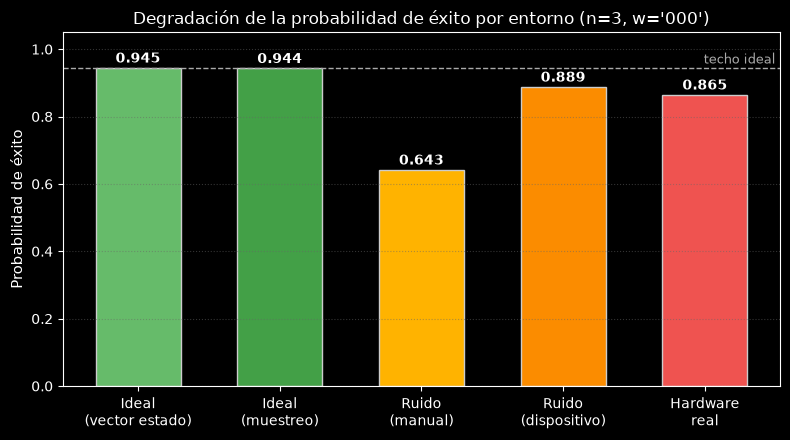

In [19]:
# === 8.6 Figura: degradación de la probabilidad de éxito por entorno ===
import matplotlib.pyplot as plt
plt.style.use("default")

entornos, valores, colores = [], [], []
entornos.append("Ideal\n(vector estado)"); valores.append(p_exact);        colores.append("#66bb6a")
entornos.append("Ideal\n(muestreo)");     valores.append(p_ideal);        colores.append("#43a047")
entornos.append("Ruido\n(manual)");       valores.append(p_noisy_manual); colores.append("#ffb300")
if ("p_noisy_backend" in globals()) and (p_noisy_backend is not None):
    entornos.append("Ruido\n(dispositivo)"); valores.append(p_noisy_backend); colores.append("#fb8c00")
if ("hw" in globals()) and (hw is not None) and ("p_real" in hw):
    entornos.append("Hardware\nreal"); valores.append(hw["p_real"]); colores.append("#ef5350")

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="black")
ax.set_facecolor("black")

barras = ax.bar(entornos, valores, color=colores, edgecolor="#cccccc", width=0.6)
ax.axhline(p_exact, ls="--", color="#aaaaaa", lw=1)
ax.text(len(entornos) - 0.5, p_exact + 0.012, "techo ideal", color="#aaaaaa", ha="right", fontsize=9)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontweight="bold", color="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Probabilidad de éxito", color="white", fontsize=11)
ax.set_title(f"Degradación de la probabilidad de éxito por entorno (n={n}, w='{w_str}')", color="white", fontsize=12)
ax.grid(axis="y", ls=":", alpha=0.5, color="#666666")

for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color("white")
ax.tick_params(colors="white", labelsize=10)
ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
ax.title.set_color("white")

plt.tight_layout()
plt.savefig("degradacion_probabilidad.png", dpi=200, facecolor="black", bbox_inches="tight")
plt.show()

## 8.7 Figura: escalabilidad de las consultas (clásico frente a Grover)

Esta figura muestra cómo crece el número de consultas al oráculo al aumentar el tamaño del espacio de búsqueda, comparando la búsqueda clásica en el peor caso, de orden O(N), con el número de iteraciones de Grover, de orden O(√N). El crecimiento mucho más lento del caso cuántico evidencia la ventaja cuadrática del algoritmo, que no depende de la instancia pequeña estudiada y se hace más notable a medida que crece N.

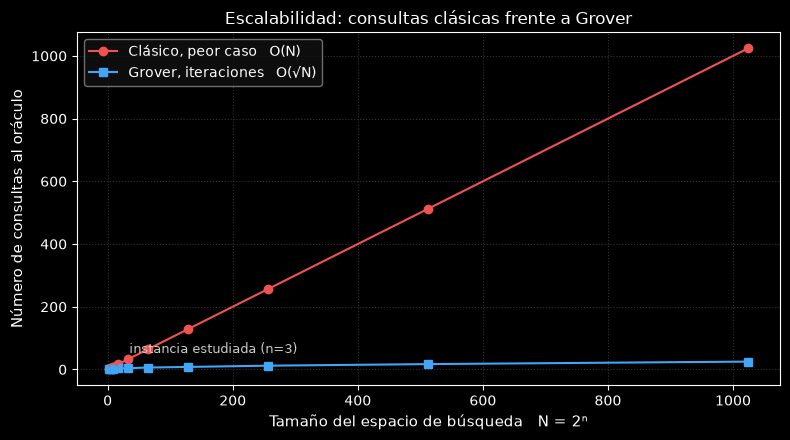

In [20]:
# === 8.7 Figura: escalabilidad consultas clásicas vs Grover ===
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")

ns = np.arange(1, 11)              # n = 1..10  ->  N = 2..1024
Ns = 2 ** ns
clasico = Ns                       # peor caso, O(N)
grover = np.floor((np.pi / 4) * np.sqrt(Ns)).astype(int)   # iteraciones óptimas, O(√N)

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="black")
ax.set_facecolor("black")

ax.plot(Ns, clasico, "o-", color="#ef5350", label="Clásico, peor caso   O(N)")
ax.plot(Ns, grover,  "s-", color="#42a5f5", label="Grover, iteraciones   O(√N)")
ax.scatter([8], [8], color="#ef5350", zorder=5)
ax.scatter([8], [2], color="#42a5f5", zorder=5)
ax.annotate("instancia estudiada (n=3)", (8, 8),
            textcoords="offset points", xytext=(12, 10), fontsize=9, color="#cccccc")
ax.set_xlabel("Tamaño del espacio de búsqueda   N = 2ⁿ", color="white", fontsize=11)
ax.set_ylabel("Número de consultas al oráculo", color="white", fontsize=11)
ax.set_title("Escalabilidad: consultas clásicas frente a Grover", color="white", fontsize=12)
ax.grid(ls=":", alpha=0.5, color="#666666")

leg = ax.legend(facecolor="#111111", edgecolor="#888888")
for t in leg.get_texts():
    t.set_color("white")

for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color("white")
ax.tick_params(colors="white", labelsize=10)
ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
ax.title.set_color("white")

plt.tight_layout()
plt.savefig("escalabilidad_consultas.png", dpi=200, facecolor="black", bbox_inches="tight")
plt.show()